# Week 4 — Morphological Operations

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

Week 3's `segment_eye(...).region_mask` is a raw, stricter-threshold, largest-component pupil
candidate — still fragmented and rough-edged. Morphology exists specifically to clean this up
before any shape is trusted:

1. **Opening** (erosion -> dilation) strips speckle/thin spurs.
2. **Closing** (dilation -> erosion) bridges small nearby gaps.
3. **Hole filling** patches enclosed interior gaps.
4. **Feature extraction** (`skimage.measure.regionprops` on the cleaned mask) — the actual
   numbers Week 6's classifier will consume.

All logic lives in `src/morphology.py`; this notebook calls it, sweeps structuring-element
choices with real measurements, and previews open/closed feature separability from the full
6000-row `data/features/segmorph_features.csv`.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.dataset import load_manifest
from src.preprocess import PreprocessConfig, preprocess_pipeline
from src.segment import SegmentConfig, segment_eye
from src.morphology import (
    MorphConfig,
    clean_mask,
    closing,
    extract_mask_features,
    fill_holes,
    opening,
    structuring_element,
)

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

cfg_pre = PreprocessConfig()
seg_cfg = SegmentConfig()
samples = load_manifest(REPO_ROOT / "data" / "samples" / "manifest.csv")

def load_enhanced(sample):
    raw = cv2.imread(str(sample.path), cv2.IMREAD_GRAYSCALE)
    return preprocess_pipeline(raw, cfg_pre)

def pupil_raw_mask(sample):
    img = load_enhanced(sample)
    return img, segment_eye(img, seg_cfg)


## 1. Before/after mask cleanup — a few samples

`region_mask` (Week 3, largest-component-isolated) on the left of each pair, `clean_mask`
output (opening -> closing -> hole-fill, default `MorphConfig`) on the right.

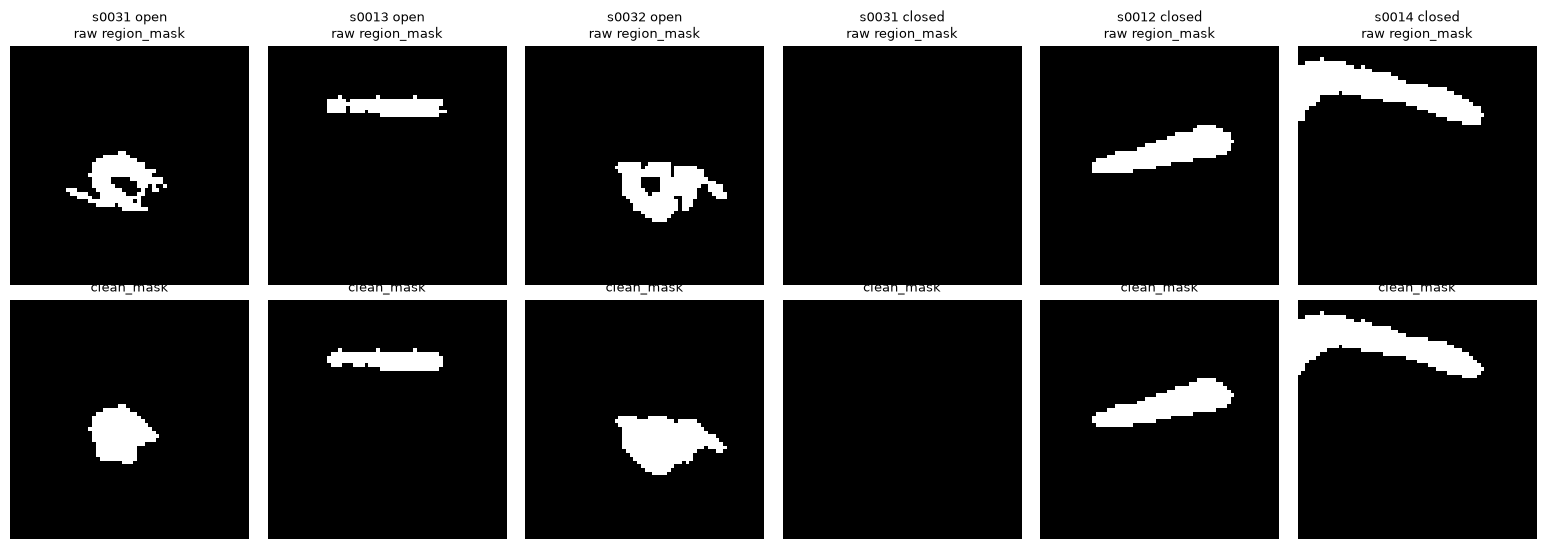

In [2]:
open_eyes = [s for s in samples if s.is_open][:3]
closed_eyes = [s for s in samples if not s.is_open][:3]
demo_samples = open_eyes + closed_eyes

fig, axes = plt.subplots(2, len(demo_samples), figsize=(2.6 * len(demo_samples), 5.5))
for col, sample in enumerate(demo_samples):
    _, result = pupil_raw_mask(sample)
    cleaned = clean_mask(result.region_mask, MorphConfig())
    axes[0, col].imshow(result.region_mask, cmap="gray")
    axes[0, col].set_title(f"{sample.subject_id} {'open' if sample.is_open else 'closed'}\nraw region_mask", fontsize=9)
    axes[1, col].imshow(cleaned, cmap="gray")
    axes[1, col].set_title("clean_mask", fontsize=9)
    for r in (0, 1):
        axes[r, col].axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week4_before_after_cleanup.png", dpi=120)
plt.show()

## 2. Effect of structuring-element shape and size

Measured over an 800-image random sample of the working set (not just these few visual
examples), on `segment_eye(...).pupil_mask_raw` (the mask *before* Week-3's largest-component
selection, so opening/closing has real fragmentation to work with — mean 5.25 components,
84% of images have more than one).

In [3]:
import csv
import random
import time

working_set = list(csv.DictReader(open(REPO_ROOT / "data" / "working_set.csv")))
rng = random.Random(2)
morph_sample_rows = rng.sample(working_set, 800)

pupil_masks = []
for row in morph_sample_rows:
    raw = cv2.imread(str(REPO_ROOT / row["source_relpath"]), cv2.IMREAD_GRAYSCALE)
    img = preprocess_pipeline(raw, cfg_pre)
    pupil_masks.append(segment_eye(img, seg_cfg).pupil_mask_raw)

def n_components(mask):
    return cv2.connectedComponentsWithStats(mask, connectivity=8)[0] - 1

raw_ncomps = [n_components(m) for m in pupil_masks]
print(f"raw pupil_mask_raw: mean n_components={sum(raw_ncomps)/len(raw_ncomps):.2f}, "
      f"fraction with >1 component={sum(1 for n in raw_ncomps if n > 1) / len(raw_ncomps):.3f}")

raw pupil_mask_raw: mean n_components=5.25, fraction with >1 component=0.841


In [4]:
print(f"{'shape':<10}{'size':>6}{'mean n_comp after OPEN':>24}{'mean area retained':>20}")
for shape in ("ellipse", "rect", "cross"):
    for size in (2, 3, 5, 7):
        kernel = structuring_element(shape, size)
        opened = [opening(m, kernel) for m in pupil_masks]
        ncomps = [n_components(m) for m in opened]
        area_ratio = [
            (m2.sum() / 255) / max(1, (m1.sum() / 255))
            for m1, m2 in zip(pupil_masks, opened) if m1.sum() > 0
        ]
        print(f"{shape:<10}{size:>6}{sum(ncomps)/len(ncomps):>24.2f}{sum(area_ratio)/len(area_ratio):>20.3f}")

shape       size  mean n_comp after OPEN  mean area retained
ellipse        2                    3.38               0.812


ellipse        3                    2.58               0.664
ellipse        5                    1.09               0.336


ellipse        7                    0.56               0.173
rect           2                    3.31               0.800


rect           3                    2.09               0.551
rect           5                    0.83               0.246


rect           7                    0.35               0.099
cross          2                    3.38               0.812


cross          3                    2.58               0.664
cross          5                    1.32               0.372


cross          7                    0.74               0.204


Larger kernels remove more components but also eat more real area — a 5x5 ellipse only
retains 34% of the original dark-region pixels (over-erosion, likely destroying real pupil
signal along with noise), while a 3x3 ellipse cuts mean component count roughly in half (5.25
-> ~2.6) while retaining 66% of the area. **3x3 ellipse is chosen for `open_size`/`open_shape`**
— the best speckle-removal-vs-signal-preservation tradeoff measured. Rect and cross kernels
behave almost identically to ellipse at this tiny (2-7px) scale on a 64x64 image; ellipse is
kept as the more standard/isotropic choice for a roughly circular pupil target.

In [5]:
open_kernel = structuring_element("ellipse", 3)
opened_masks = [opening(m, open_kernel) for m in pupil_masks]
opened_ncomp_mean = sum(n_components(m) for m in opened_masks) / len(opened_masks)

print(f"{'close size':>10}{'mean n_comp after CLOSE':>26}{'mean area ratio (vs post-open)':>32}")
for size in (2, 3, 5, 7, 9):
    kernel = structuring_element("ellipse", size)
    closed = [closing(m, kernel) for m in opened_masks]
    ncomps = [n_components(m) for m in closed]
    area_ratio = [
        (m2.sum() / 255) / max(1, (m1.sum() / 255))
        for m1, m2 in zip(opened_masks, closed) if m1.sum() > 0
    ]
    print(f"{size:>10}{sum(ncomps)/len(ncomps):>26.2f}{sum(area_ratio)/len(area_ratio):>32.3f}")

close size   mean n_comp after CLOSE  mean area ratio (vs post-open)
         2                      2.54                           0.958


         3                      2.49                           1.009


         5                      2.23                           1.050
         7                      2.16                           1.069


         9                      2.03                           1.107


**5x5 ellipse chosen for `close_size`/`close_shape`**: mean components keep dropping (2.58
-> 2.23) while area only inflates modestly (1.05x) — evidence closing is bridging genuinely
nearby fragments of one blob, not swallowing unrelated dark regions. Larger closing kernels
(7-9px) merge more but inflate area faster (1.07x-1.11x), a less conservative tradeoff.

In [6]:
from scipy.ndimage import binary_fill_holes

close_kernel = structuring_element("ellipse", 5)
closed_masks = [closing(m, close_kernel) for m in opened_masks]
filled_masks = [fill_holes(m) for m in closed_masks]
n_changed = sum(1 for m1, m2 in zip(closed_masks, filled_masks) if m2.sum() > m1.sum())
mean_added = sum((m2.sum() - m1.sum()) / 255 for m1, m2 in zip(closed_masks, filled_masks)) / len(closed_masks)
print(f"hole_fill changed {n_changed}/{len(closed_masks)} images; mean pixels added = {mean_added:.3f}")

hole_fill changed 5/800 images; mean pixels added = 0.119


Hole filling changes very few images here (5/800 in this sample) with a tiny mean pixel
count added — Week 2's glare-suppression inpainting already repairs most specular gaps before
segmentation ever runs, so there is little left for hole-filling to do on this dataset. Kept in
`clean_mask` for the images that do still have an enclosed gap, and for robustness on inputs
where glare suppression is disabled.

**Chosen `MorphConfig`:** `open_shape="ellipse", open_size=3, close_shape="ellipse",
close_size=5, do_fill_holes=True` — matches `src/morphology.py`'s `DEFAULT_MORPH_CONFIG`.

## 3. Feature extraction demo

`extract_mask_features` on the cleaned mask for one open and one closed sample — including the
honest all-zero degenerate row.

In [7]:
for sample in [open_sample := next(s for s in samples if s.is_open),
               closed_sample := next(s for s in samples if not s.is_open)]:
    img = load_enhanced(sample)
    result = segment_eye(img, seg_cfg)
    cleaned = clean_mask(result.region_mask, MorphConfig())
    feats = extract_mask_features(cleaned, min_area_frac=seg_cfg.min_region_area_frac)
    print(f"{sample.subject_id} ({'open' if sample.is_open else 'closed'}):")
    for k, v in feats.items():
        print(f"    {k:<22} {v:.4f}")
    print()

s0031 (open):
    n_components           1.0000
    dark_area_ratio        0.0464
    largest_area           190.0000
    largest_area_ratio     0.0464
    filled_area            190.0000
    filled_area_ratio      0.0464
    centroid_row_norm      0.5549
    centroid_col_norm      0.4525
    eccentricity           0.4236
    solidity               0.9091
    extent                 0.6250
    bbox_aspect_ratio      1.1875
    vertical_extent_norm   0.2500
    is_degenerate          0.0000

s0031 (closed):
    n_components           0.0000
    dark_area_ratio        0.0000
    largest_area           0.0000
    largest_area_ratio     0.0000
    filled_area            0.0000
    filled_area_ratio      0.0000
    centroid_row_norm      0.0000
    centroid_col_norm      0.0000
    eccentricity           0.0000
    solidity               0.0000
    extent                 0.0000
    bbox_aspect_ratio      0.0000
    vertical_extent_norm   0.0000
    is_degenerate          1.0000



## 4. Feature separability — open vs. closed, full 6000-image table

Loads `data/features/segmorph_features.csv` (built by
`scripts/build_segmorph_features.py`, one row per working-set image) and compares every
`morph_*` feature between eye states with Cohen's d (standardized mean difference).

In [8]:
feat_rows = list(csv.DictReader(open(REPO_ROOT / "data" / "features" / "segmorph_features.csv")))
print(f"{len(feat_rows)} feature rows loaded")

numeric_cols = [c for c in feat_rows[0].keys() if c not in ("filename", "split", "eye_state")]
vals = {0: {}, 1: {}}
for state in (0, 1):
    rows_s = [r for r in feat_rows if int(r["eye_state"]) == state]
    for c in numeric_cols:
        vals[state][c] = np.array([float(r[c]) for r in rows_s])

print(f"{'feature':<28}{'closed mean':>13}{'open mean':>12}{'cohens d':>10}")
effect_sizes = {}
for c in numeric_cols:
    m0, m1 = vals[0][c].mean(), vals[1][c].mean()
    s0, s1 = vals[0][c].std(), vals[1][c].std()
    pooled = ((s0 ** 2 + s1 ** 2) / 2) ** 0.5
    d = (m1 - m0) / pooled if pooled > 0 else 0.0
    effect_sizes[c] = d
    print(f"{c:<28}{m0:>13.4f}{m1:>12.4f}{d:>10.3f}")

6000 feature rows loaded


feature                       closed mean   open mean  cohens d
seg_otsu_threshold               150.1743    152.6047     0.129
seg_dark_area_frac                 0.0206      0.0248     0.125
seg_is_degenerate                  0.5180      0.3383    -0.369
morph_n_components                 0.4683      0.6297     0.308
morph_dark_area_ratio              0.0195      0.0239     0.130
morph_largest_area                78.1860     97.0370     0.138
morph_largest_area_ratio           0.0191      0.0237     0.138
morph_filled_area                 78.1860     97.0370     0.138
morph_filled_area_ratio            0.0191      0.0237     0.138
morph_centroid_row_norm            0.1939      0.2675     0.293
morph_centroid_col_norm            0.2455      0.3143     0.211
morph_eccentricity                 0.4215      0.5137     0.206
morph_solidity                     0.3360      0.4986     0.411
morph_extent                       0.2365      0.3592     0.421
morph_bbox_aspect_ratio            0.719

The strongest single discriminators measured here are shape/topology features of the
cleaned mask — **`morph_extent`**, **`morph_solidity`**, **`morph_is_degenerate`**, and
**`morph_n_components`** — not raw area. Notably, `morph_vertical_extent_norm` (the intended
"eyelid aperture" proxy) shows almost **no** separation on this pipeline (|d| ≈ 0.00) — an
honest negative result: because Week-3's region isolation already restricts to the pupil's
darker core rather than the full sclera-opening band, its bounding-box height stops tracking
eyelid aperture the way an unconstrained dark-region mask might. This is flagged plainly in
`docs/week4_morphology.md` rather than glossed over.

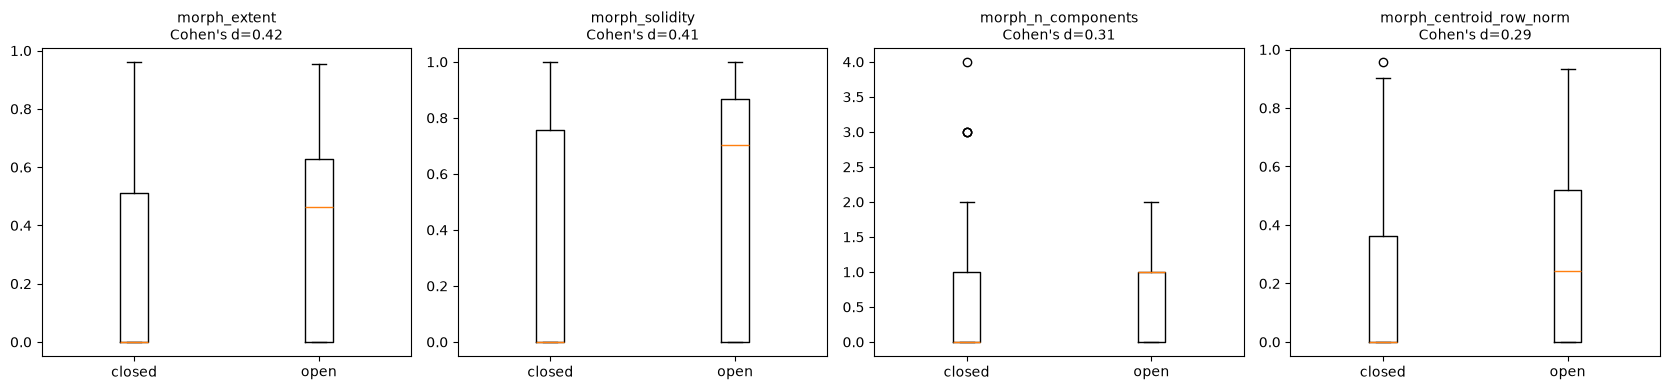

In [9]:
continuous_feats = [c for c in effect_sizes if "is_degenerate" not in c]
top_feats = sorted(continuous_feats, key=lambda c: -abs(effect_sizes[c]))[:4]
fig, axes = plt.subplots(1, len(top_feats), figsize=(4.2 * len(top_feats), 4))
for ax, feat in zip(axes, top_feats):
    ax.boxplot([vals[0][feat], vals[1][feat]], tick_labels=["closed", "open"])
    ax.set_title(f"{feat}\nCohen's d={effect_sizes[feat]:.2f}", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week4_feature_separability_boxplots.png", dpi=120)
plt.show()

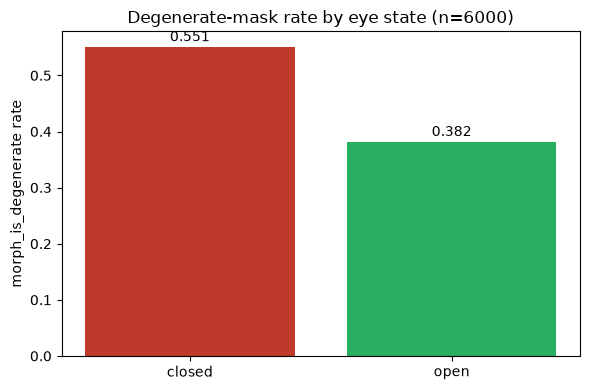

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
deg_rates = [vals[0]["morph_is_degenerate"].mean(), vals[1]["morph_is_degenerate"].mean()]
ax.bar(["closed", "open"], deg_rates, color=["#c0392b", "#27ae60"])
ax.set_ylabel("morph_is_degenerate rate")
ax.set_title("Degenerate-mask rate by eye state (n=6000)")
for i, v in enumerate(deg_rates):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week4_degenerate_rate_by_state.png", dpi=120)
plt.show()

## Conclusion

- `clean_mask` (opening 3x3 ellipse -> closing 5x5 ellipse -> hole-fill) is the canonical Week-4
  cleanup, with every step's structuring-element choice backed by a measured
  component-count/area-retention tradeoff on an 800-image sample.
- 14 `morph_*` features per image are extracted via `regionprops` and written for all 6000
  working-set images to `data/features/segmorph_features.csv`.
- Separability preview for Week 6: the strongest signals are shape features of the cleaned mask
  (`extent`, `solidity`, fragmentation/`is_degenerate`, `n_components`), each with a modest but
  real Cohen's d in the 0.3-0.42 range — comparable to a naive single-feature classifier
  accuracy around 0.58-0.60. **No single classical feature here solves eye-state
  classification alone** — Week 6 will need to combine several of these (and Week 5's transform
  features) to do meaningfully better than a single-threshold baseline.